In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import os
import time
import hashlib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ Бібліотеки завантажено")

✅ Бібліотеки завантажено


In [7]:
# Словник областей України (англійська назва -> українська назва)
REGIONS_UK = {
    1: "Черкаська",
    2: "Чернігівська",
    3: "Чернівецька",
    4: "Дніпропетровська",
    5: "Донецька",
    6: "Івано-Франківська",
    7: "Харківська",
    8: "Херсонська",
    9: "Хмельницька",
    10: "Київська",
    11: "Кіровоградська",
    12: "Луганська",
    13: "Львівська",
    14: "Миколаївська",
    15: "Одеська",
    16: "Полтавська",
    17: "Рівненська",
    18: "Сумська",
    19: "Тернопільська",
    20: "Закарпатська",
    21: "Вінницька",
    22: "Волинська",
    23: "Запорізька",
    24: "Житомирська"
}

# Словник для сортування за українською абеткою
UKRAINIAN_ALPHABET_ORDER = {
    "Вінницька": 1, "Волинська": 2, "Дніпропетровська": 3, "Донецька": 4,
    "Житомирська": 5, "Закарпатська": 6, "Запорізька": 7, "Івано-Франківська": 8,
    "Київська": 9, "Кіровоградська": 10, "Луганська": 11, "Львівська": 12,
    "Миколаївська": 13, "Одеська": 14, "Полтавська": 15, "Рівненська": 16,
    "Сумська": 17, "Тернопільська": 18, "Харківська": 19, "Херсонська": 20,
    "Хмельницька": 21, "Черкаська": 22, "Чернівецька": 23, "Чернігівська": 24
}

def get_file_path(province_id, data_dir="vhi_data"):
    """Повертає шлях до файлу для області"""
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return os.path.join(data_dir, f"vhi_province_{province_id}_{timestamp}.txt")

def file_already_downloaded(province_id, data_dir="vhi_data"):
    """Перевіряє, чи вже завантажено файл для області"""
    if not os.path.exists(data_dir):
        return False
    for file in os.listdir(data_dir):
        if file.startswith(f"vhi_province_{province_id}_"):
            return True
    return False

def download_vhi_data(province_id, force_download=False):
    """
    Завантажує VHI дані для вказаної області
    province_id: 1-24 (або 0 для середнього по Україні)
    """
    if province_id == 0:
        print("Пропускаємо provinceID=0 (середнє по Україні)")
        return None

    if not force_download and file_already_downloaded(province_id):
        print(f"Область {province_id} вже завантажена, пропускаємо...")
        return None

    url = f"https://www.star.nesdis.noaa.gov/smcd/emb/vci/VH/get_TS_admin.php?country=UKR&provinceID={province_id}&year1=1981&year2=2024&type=Mean"

    try:
        file_path = get_file_path(province_id)
        urllib.request.urlretrieve(url, file_path)
        print(f"✅ Завантажено область {province_id}: {REGIONS_UK.get(province_id, 'Невідома')}")
        return file_path
    except Exception as e:
        print(f"❌ Помилка завантаження області {province_id}: {e}")
        return None

def download_all_regions():
    """Завантажує дані для всіх областей України"""
    print("Початок завантаження даних для областей України...")
    start_time = time.time()

    for province_id in range(1, 25):
        download_vhi_data(province_id)

    elapsed = time.time() - start_time
    print(f"✅ Завантаження завершено за {elapsed:.2f} секунд")

# Завантаження всіх областей
download_all_regions()

Початок завантаження даних для областей України...
Область 1 вже завантажена, пропускаємо...
Область 2 вже завантажена, пропускаємо...
Область 3 вже завантажена, пропускаємо...
Область 4 вже завантажена, пропускаємо...
Область 5 вже завантажена, пропускаємо...
Область 6 вже завантажена, пропускаємо...
Область 7 вже завантажена, пропускаємо...
Область 8 вже завантажена, пропускаємо...
Область 9 вже завантажена, пропускаємо...
Область 10 вже завантажена, пропускаємо...
Область 11 вже завантажена, пропускаємо...
Область 12 вже завантажена, пропускаємо...
Область 13 вже завантажена, пропускаємо...
Область 14 вже завантажена, пропускаємо...
Область 15 вже завантажена, пропускаємо...
Область 16 вже завантажена, пропускаємо...
Область 17 вже завантажена, пропускаємо...
Область 18 вже завантажена, пропускаємо...
Область 19 вже завантажена, пропускаємо...
Область 20 вже завантажена, пропускаємо...
Область 21 вже завантажена, пропускаємо...
Область 22 вже завантажена, пропускаємо...
Область 23 в

In [8]:
def read_vhi_file(file_path, province_id):
    """
    Зчитує VHI файл та повертає cleaned DataFrame
    """
    try:
        # Спочатку подивимось, скільки колонок у файлі
        with open(file_path, 'r') as f:
            first_line = f.readline()
            print(f"Debug - перший рядок файлу {province_id}: {first_line[:200]}")

        # Читання файлу з пропуском перших рядків
        df = pd.read_csv(file_path, skiprows=2, header=None)

        print(f"Debug - форма df для {province_id}: {df.shape}")

        # Перевірка кількості колонок
        if df.shape[1] == 5:
            df.columns = ['Year', 'Week', 'VCI', 'TCI', 'VHI']
        elif df.shape[1] == 6:
            df.columns = ['Year', 'Week', 'VCI', 'TCI', 'VHI', 'Extra']
            df = df.drop('Extra', axis=1)
        elif df.shape[1] == 8:
            # Можливо файл має додаткові колонки
            df.columns = ['Year', 'Week', 'VCI', 'TCI', 'VHI', 'Col6', 'Col7', 'Col8']
            df = df[['Year', 'Week', 'VCI', 'TCI', 'VHI']]  # Беремо тільки потрібні
        else:
            # Якщо кількість колонок інша, спробуємо визначити автоматично
            print(f"⚠️ Невідома кількість колонок: {df.shape[1]}")
            # Беремо перші 5 колонок
            df = df.iloc[:, :5]
            df.columns = ['Year', 'Week', 'VCI', 'TCI', 'VHI']

        # Додавання інформації про область
        df['Province_ID'] = province_id
        df['Province_Name_En'] = REGIONS_UK.get(province_id, "Unknown")
        df['Province_Name_Ua'] = REGIONS_UK.get(province_id, "Невідома")

        # Очищення: заміна спеціальних значень на NaN
        df = df.replace(-9999, np.nan)
        df = df.replace(-999, np.nan)
        df = df.replace('NaN', np.nan)

        # Конвертація типів
        df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
        df['Week'] = pd.to_numeric(df['Week'], errors='coerce')
        df['VCI'] = pd.to_numeric(df['VCI'], errors='coerce')
        df['TCI'] = pd.to_numeric(df['TCI'], errors='coerce')
        df['VHI'] = pd.to_numeric(df['VHI'], errors='coerce')

        # Видалення рядків з пропусками в основних колонках
        df = df.dropna(subset=['Year', 'Week'])

        # Видалення зайвих стовпців (де всі значення NaN)
        df = df.dropna(axis=1, how='all')

        print(f"✅ Завантажено область {province_id}: {len(df)} записів")
        return df

    except Exception as e:
        print(f"❌ Помилка читання файлу {file_path}: {e}")
        return None

def load_all_vhi_data(data_dir="vhi_data"):
    """
    Завантажує всі VHI файли в один DataFrame
    """
    all_data = []

    # Отримуємо список файлів
    files = [f for f in os.listdir(data_dir) if f.startswith("vhi_province_")]
    print(f"Знайдено файлів: {len(files)}")

    for file in files:
        try:
            # Витягуємо province_id з імені файлу
            parts = file.split('_')
            province_id = int(parts[2])
            file_path = os.path.join(data_dir, file)
            df = read_vhi_file(file_path, province_id)
            if df is not None and len(df) > 0:
                all_data.append(df)
            else:
                print(f"⚠️ Немає даних для файлу {file}")
        except Exception as e:
            print(f"⚠️ Помилка обробки файлу {file}: {e}")
            continue

    if all_data:
        combined_df = pd.concat(all_data, ignore_index=True)
        print(f"✅ Завантажено {len(combined_df)} записів для {len(all_data)} областей")
        return combined_df
    else:
        print("❌ Дані не знайдено")
        return None

# Перевірка вмісту файлу перед завантаженням
def preview_vhi_file(file_path):
    """Показує перші рядки файлу для діагностики"""
    print(f"\nПерегляд файлу: {file_path}")
    with open(file_path, 'r') as f:
        lines = f.readlines()[:10]
        for i, line in enumerate(lines):
            print(f"Рядок {i+1}: {line.strip()[:150]}")

# Подивимось перший файл для діагностики
if os.path.exists("vhi_data"):
    files = [f for f in os.listdir("vhi_data") if f.startswith("vhi_province_")]
    if files:
        preview_vhi_file(os.path.join("vhi_data", files[0]))

# Завантаження всіх даних
vhi_df = load_all_vhi_data()

# Перевірка, чи дані завантажились
if vhi_df is not None:
    print(f"\n✅ Дані успішно завантажено!")
    print(f"Форма даних: {vhi_df.shape}")
    vhi_df.head()
else:
    print("\n❌ Не вдалося завантажити дані. Перевірте структуру файлів.")


Перегляд файлу: vhi_data/vhi_province_1_20260513_185234.txt
Рядок 1: Mean data for UKR  Province= 1: Cherkasy,  from 1981 to 2024, weekly; version='GC_current'<br>for cropland area only<br>
Рядок 2: year,week, SMN,SMT,VCI,TCI, VHI<br>
Рядок 3: <tt><pre>1982, 1, 0.053,260.31, 45.01, 39.46, 42.23,
Рядок 4: 1982, 2, 0.054,262.29, 46.83, 31.75, 39.29,
Рядок 5: 1982, 3, 0.055,263.82, 48.13, 27.24, 37.68,
Рядок 6: 1982, 4, 0.053,265.33, 46.09, 23.91, 35.00,
Рядок 7: 1982, 5, 0.050,265.66, 41.46, 26.65, 34.06,
Рядок 8: 1982, 6, 0.048,266.55, 36.56, 29.46, 33.01,
Рядок 9: 1982, 7, 0.048,267.84, 32.17, 31.14, 31.65,
Рядок 10: 1982, 8, 0.050,269.30, 30.30, 32.50, 31.40,
Знайдено файлів: 24
Debug - перший рядок файлу 1: Mean data for UKR  Province= 1: Cherkasy,  from 1981 to 2024, weekly; version='GC_current'<br>for cropland area only<br>

Debug - форма df для 1: (2237, 8)
✅ Завантажено область 1: 2235 записів
Debug - перший рядок файлу 11: Mean data for UKR  Province= 11: Kiev,  from 1981 to 20

In [9]:
def reindex_by_ukrainian_alphabet(df):
    """
    Переіндексовує області за українською абеткою
    """
    df = df.copy()

    # Створення мапи для нового індексу
    df['New_Index'] = df['Province_Name_Ua'].map(UKRAINIAN_ALPHABET_ORDER)

    # Сортування за новим індексом
    df = df.sort_values('New_Index')

    print("✅ Переіндексацію виконано")
    print(f"Приклад: {df[['Province_Name_Ua', 'New_Index']].drop_duplicates().head(10)}")

    return df

vhi_df = reindex_by_ukrainian_alphabet(vhi_df)

✅ Переіндексацію виконано
Приклад:         Province_Name_Ua  New_Index
37976          Вінницька          1
33544          Волинська          2
40220   Дніпропетровська          3
31303           Донецька          4
20137        Житомирська          5
29077       Закарпатська          6
51326         Запорізька          7
42467  Івано-Франківська          8
17922           Київська          9
2269      Кіровоградська         10


In [10]:
def get_vhi_by_year(df, region_name, year):
    """
    Повертає ряд VHI для області за вказаний рік
    """
    result = df[(df['Province_Name_Ua'] == region_name) & (df['Year'] == year)]
    print(f"📊 VHI для області '{region_name}' за {year} рік: {len(result)} записів")
    return result

def get_vhi_by_year_range(df, regions, start_year, end_year):
    """
    Повертає ряд VHI за вказаний діапазон років для вказаних областей
    """
    if isinstance(regions, str):
        regions = [regions]

    result = df[(df['Province_Name_Ua'].isin(regions)) &
                (df['Year'] >= start_year) &
                (df['Year'] <= end_year)]

    print(f"📊 VHI для областей {regions} за {start_year}-{end_year} роки: {len(result)} записів")
    return result

def get_extremes(df, regions, years):
    """
    Пошук екстремумів (min та max) для вказаних областей та років
    Повертає також середнє та медіану
    """
    if isinstance(regions, str):
        regions = [regions]
    if isinstance(years, int):
        years = [years]

    filtered = df[(df['Province_Name_Ua'].isin(regions)) & (df['Year'].isin(years))]

    stats = {
        'min': filtered['VHI'].min(),
        'max': filtered['VHI'].max(),
        'mean': filtered['VHI'].mean(),
        'median': filtered['VHI'].median(),
        'std': filtered['VHI'].std(),
        'count': len(filtered)
    }

    print(f"📊 Статистика VHI для областей {regions} за роки {years}:")
    for key, value in stats.items():
        print(f"   {key}: {value:.2f}" if isinstance(value, float) else f"   {key}: {value}")

    return stats

def get_region_statistics(df, region_name):
    """
    Повертає повну статистику для області за всі роки
    """
    region_data = df[df['Province_Name_Ua'] == region_name]

    print(f"\n📊 Статистика для області {region_name}:")
    print(f"   Період: {region_data['Year'].min()} - {region_data['Year'].max()}")
    print(f"   Кількість записів: {len(region_data)}")
    print(f"   Середній VHI: {region_data['VHI'].mean():.2f}")
    print(f"   Медіана VHI: {region_data['VHI'].median():.2f}")
    print(f"   Мінімальний VHI: {region_data['VHI'].min():.2f} (рік {region_data.loc[region_data['VHI'].idxmin(), 'Year']})")
    print(f"   Максимальний VHI: {region_data['VHI'].max():.2f} (рік {region_data.loc[region_data['VHI'].idxmax(), 'Year']})")

    return region_data

In [11]:
# Приклад 1: VHI для області за рік
print("="*60)
print("ПРИКЛАД 1: VHI для Вінницької області за 2020 рік")
print("="*60)
vhi_2020 = get_vhi_by_year(vhi_df, "Вінницька", 2020)
vhi_2020.head()

ПРИКЛАД 1: VHI для Вінницької області за 2020 рік
📊 VHI для області 'Вінницька' за 2020 рік: 52 записів


,Year,Week,VCI,TCI,VHI,Province_ID,Province_Name_En,Province_Name_Ua,New_Index
37786,2020.0,52.0,0.042,256.50,24.67,21,Вінницька,Вінницька,1
37785,2020.0,51.0,0.045,258.85,24.35,21,Вінницька,Вінницька,1
37784,2020.0,50.0,0.049,261.01,24.65,21,Вінницька,Вінницька,1
37783,2020.0,49.0,0.053,262.92,24.25,21,Вінницька,Вінницька,1
37782,2020.0,48.0,0.057,265.18,21.82,21,Вінницька,Вінницька,1


In [12]:
# Приклад 2: VHI за діапазон років для кількох областей
print("="*60)
print("ПРИКЛАД 2: VHI для Київської та Львівської областей за 2015-2020 роки")
print("="*60)
vhi_range = get_vhi_by_year_range(vhi_df, ["Київська", "Львівська"], 2015, 2020)
vhi_range.head()

ПРИКЛАД 2: VHI для Київської та Львівської областей за 2015-2020 роки
📊 VHI для областей ['Київська', 'Львівська'] за 2015-2020 роки: 624 записів


,Year,Week,VCI,TCI,VHI,Province_ID,Province_Name_En,Province_Name_Ua,New_Index
19595,2015.0,1.0,0.057,256.27,45.91,10,Київська,Київська,9
19596,2015.0,2.0,0.059,255.97,50.00,10,Київська,Київська,9
19597,2015.0,3.0,0.065,257.98,57.38,10,Київська,Київська,9
19598,2015.0,4.0,0.070,260.68,61.66,10,Київська,Київська,9
19611,2015.0,17.0,0.299,292.87,65.80,10,Київська,Київська,9


In [13]:
# Приклад 3: Екстремуми та статистика
print("="*60)
print("ПРИКЛАД 3: Статистика VHI для Одеської області за 2010-2020 роки")
print("="*60)
stats = get_extremes(vhi_df, "Одеська", range(2010, 2021))

ПРИКЛАД 3: Статистика VHI для Одеської області за 2010-2020 роки
📊 Статистика VHI для областей ['Одеська'] за роки range(2010, 2021):
   min: 15.71
   max: 92.95
   mean: 66.07
   median: 70.85
   std: 18.09
   count: 572


In [14]:
# Приклад 4: Повна статистика для області
print("="*60)
print("ПРИКЛАД 4: Повна статистика для Харківської області")
print("="*60)
region_stats = get_region_statistics(vhi_df, "Харківська")

ПРИКЛАД 4: Повна статистика для Харківської області

📊 Статистика для області Харківська:
   Період: 1982.0 - 2024.0
   Кількість записів: 2235
   Середній VHI: 53.21
   Медіана VHI: 55.03
   Мінімальний VHI: -1.00 (рік 2005.0)
   Максимальний VHI: 99.09 (рік 2006.0)


ПРИКЛАД 5: Візуалізація VHI для кількох областей


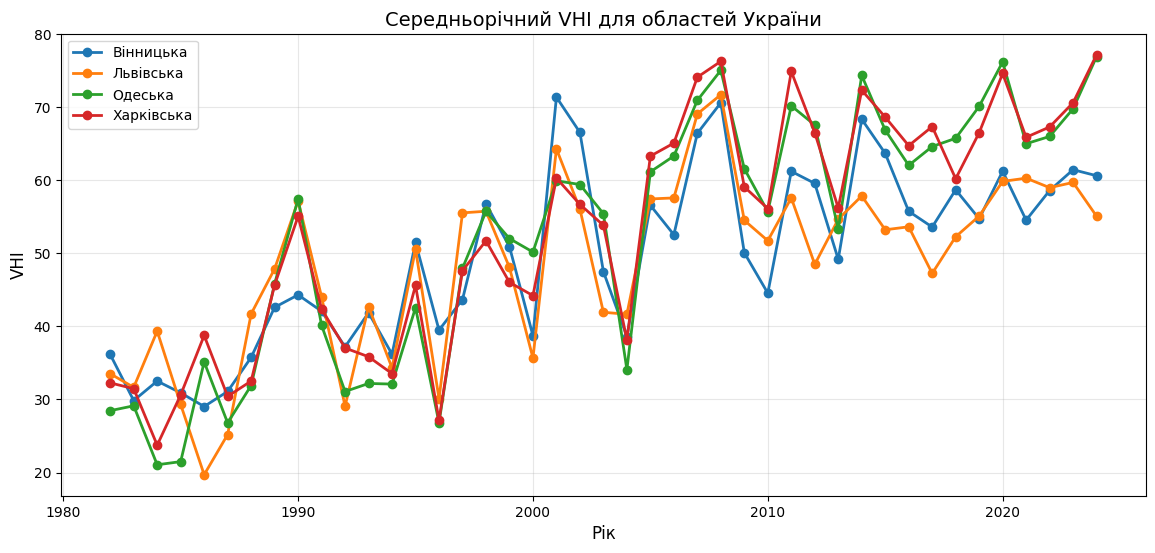

In [15]:
# Приклад 5: Візуалізація VHI для кількох областей
print("="*60)
print("ПРИКЛАД 5: Візуалізація VHI для кількох областей")
print("="*60)

plt.figure(figsize=(14, 6))
regions_to_plot = ["Вінницька", "Львівська", "Одеська", "Харківська"]

for region in regions_to_plot:
    region_data = vhi_df[vhi_df['Province_Name_Ua'] == region]
    yearly_avg = region_data.groupby('Year')['VHI'].mean()
    plt.plot(yearly_avg.index, yearly_avg.values, marker='o', label=region, linewidth=2)

plt.title('Середньорічний VHI для областей України', fontsize=14)
plt.xlabel('Рік', fontsize=12)
plt.ylabel('VHI', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
import timeit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy import stats
print("Для реального виконання завантажте датасет з посилання:")
print("https://archive.ics.uci.edu/ml/machine-learning-databases/00235/")

# Генерація тестових даних (для демонстрації)
np.random.seed(42)
n_samples = 10000
test_data = pd.DataFrame({
    'Date': pd.date_range('2006-12-16', periods=n_samples, freq='h'),
    'Time': pd.date_range('00:00:00', periods=n_samples, freq='h').strftime('%H:%M:%S'),
    'Global_active_power': np.random.exponential(1.5, n_samples) + 0.2,
    'Global_reactive_power': np.random.exponential(0.5, n_samples),
    'Voltage': np.random.normal(240, 5, n_samples),
    'Global_intensity': np.random.exponential(10, n_samples),
    'Sub_metering_1': np.random.exponential(0.5, n_samples) * 10,  # Kitchen
    'Sub_metering_2': np.random.exponential(0.3, n_samples) * 10,  # Laundry
    'Sub_metering_3': np.random.exponential(0.2, n_samples) * 10   # Water heater
})

print(f"✅ Згенеровано {len(test_data)} записів для демонстрації")

Для реального виконання завантажте датасет з посилання:
https://archive.ics.uci.edu/ml/machine-learning-databases/00235/
✅ Згенеровано 10000 записів для демонстрації


In [17]:
def clean_power_data(df):
    """
    Очищення даних: заміна '?' на NaN, видалення пропусків
    """
    df_clean = df.copy()

    # Конвертація типів
    numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

    for col in numeric_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # Видалення рядків з пропусками
    df_clean = df_clean.dropna()

    print(f"✅ Після очищення: {len(df_clean)} записів")
    return df_clean

df_power_clean = test_data.copy()  # Для демонстрації
df_power_clean.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 00:00:00,00:00:00,0.903902,0.233916,235.980984,3.909467,4.080788,1.812045,1.205143
1,2006-12-16 01:00:00,01:00:00,4.715182,0.202417,242.929959,1.611179,13.731751,5.580056,1.376805
2,2006-12-16 02:00:00,02:00:00,2.175119,0.096886,246.531402,10.922933,4.606400,0.893388,0.855621
3,2006-12-16 03:00:00,03:00:00,1.569414,0.467312,233.865422,2.812845,5.033495,0.988462,0.151685
4,2006-12-16 04:00:00,04:00:00,0.454437,0.323728,248.561539,6.093869,4.578455,0.242155,1.361000


In [18]:
def filter_by_power(df, threshold=5):
    """
    Вибірка записів, де споживана потужність перевищує threshold (кВт)
    """
    result = df[df['Global_active_power'] > threshold]
    print(f"✅ Записів з потужністю > {threshold} кВт: {len(result)}")
    return result

def filter_by_current_and_appliances(df):
    """
    Вибірка записів, де сила струму 19-20A і пральна+холодильник > бойлер+кондиціонер
    """
    # Фільтр за силою струму
    mask_current = (df['Global_intensity'] >= 19) & (df['Global_intensity'] <= 20)

    # Група 1: пральна машина + холодильник (Sub_metering_2 + інше)
    group1 = df['Sub_metering_2'] + df['Sub_metering_1']
    # Група 2: бойлер + кондиціонер (Sub_metering_3 + інше)
    group2 = df['Sub_metering_3']

    mask_appliances = group1 > group2
    result = df[mask_current & mask_appliances]

    print(f"✅ Записів з струмом 19-20A та виконанням умови: {len(result)}")
    return result

def random_sample_stats(df, n=500000):
    """
    Випадкова вибірка n записів та обчислення середніх
    """
    if len(df) > n:
        sample = df.sample(n=n, random_state=42)
    else:
        sample = df

    groups = {
        'Група 1 (Кухня/холодильник)': sample['Sub_metering_1'].mean(),
        'Група 2 (Пральня)': sample['Sub_metering_2'].mean(),
        'Група 3 (Бойлер/кондиціонер)': sample['Sub_metering_3'].mean()
    }

    print(f"✅ Випадкова вибірка з {len(sample)} записів")
    for group, value in groups.items():
        print(f"   {group}: {value:.4f} кВт")

    return sample, groups

def filter_by_evening_power(df, hour_threshold=18, power_threshold=6):
    """
    Вибірка записів після 18:00 з потужністю > 6 кВт
    """
    # Для реальних даних потрібно парсити час
    # Для демонстрації використовуємо індекс

    # Симуляція часу: створюємо годину на основі індексу
    df_copy = df.copy()
    df_copy['Hour'] = df_copy.index % 24

    mask_time = df_copy['Hour'] >= hour_threshold
    mask_power = df_copy['Global_active_power'] > power_threshold

    result = df_copy[mask_time & mask_power]
    print(f"✅ Записів після {hour_threshold}:00 з потужністю > {power_threshold} кВт: {len(result)}")

    return result

def select_every_nth(df):
    """
    Обирає кожен третій результат із першої половини та кожен четвертий із другої
    """
    half = len(df) // 2
    first_half = df.iloc[:half].iloc[::3]    # Кожен 3-й з першої половини
    second_half = df.iloc[half:].iloc[::4]   # Кожен 4-й з другої половини

    result = pd.concat([first_half, second_half])
    print(f"✅ Вибрано {len(result)} записів (кожен 3-й з першої половини, кожен 4-й з другої)")
    return result

In [19]:
# Приклад 1: Записи з потужністю > 5 кВт
print("="*60)
print("ЗАВДАННЯ 1: Записи з потужністю > 5 кВт")
print("="*60)
high_power = filter_by_power(df_power_clean, 5)
high_power.head()

ЗАВДАННЯ 1: Записи з потужністю > 5 кВт
✅ Записів з потужністю > 5 кВт: 383


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
11,2006-12-16 11:00:00,11:00:00,5.455336,0.652880,235.916310,5.540599,1.166734,2.224452,0.837142
34,2006-12-17 10:00:00,10:00:00,5.255946,0.538295,235.045696,12.914705,1.102722,7.629144,0.458025
50,2006-12-18 02:00:00,02:00:00,5.439211,0.830137,244.671370,0.693924,5.830365,6.185382,4.916545
69,2006-12-18 21:00:00,21:00:00,6.701220,1.122416,235.733909,5.288764,7.211020,3.048557,0.601704
139,2006-12-21 19:00:00,19:00:00,5.551697,0.403079,238.483696,9.799111,8.754435,3.859363,3.587596


In [20]:
# Приклад 2: Записи з струмом 19-20A та умовою
print("="*60)
print("ЗАВДАННЯ 2: Записи з струмом 19-20A (пральна+холодильник > бойлер+кондиціонер)")
print("="*60)
current_filter = filter_by_current_and_appliances(df_power_clean)
current_filter.head()

ЗАВДАННЯ 2: Записи з струмом 19-20A (пральна+холодильник > бойлер+кондиціонер)
✅ Записів з струмом 19-20A та виконанням умови: 121


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
21,2006-12-16 21:00:00,21:00:00,0.425352,0.014467,243.114307,19.897148,27.564121,5.118458,4.422845
89,2006-12-19 17:00:00,17:00:00,1.158599,0.128739,247.440673,19.185675,3.554893,1.271330,1.309335
239,2006-12-25 23:00:00,23:00:00,0.492400,0.160497,243.821463,19.799889,12.727271,0.108627,0.427553
374,2006-12-31 14:00:00,14:00:00,0.310774,2.998489,248.854788,19.951642,0.657344,6.982336,1.271783
609,2007-01-10 09:00:00,09:00:00,1.958686,1.015353,241.785813,19.477038,9.637246,1.704047,4.528214


In [21]:
# Приклад 3: Випадкова вибірка та статистика
print("="*60)
print("ЗАВДАННЯ 3: Випадкова вибірка та середні групи споживання")
print("="*60)
start_time = timeit.default_timer()
sample, means = random_sample_stats(df_power_clean, 5000)  # Для демонстрації 5000
elapsed = timeit.default_timer() - start_time
print(f"⏱️ Час виконання: {elapsed:.4f} секунд")

ЗАВДАННЯ 3: Випадкова вибірка та середні групи споживання
✅ Випадкова вибірка з 5000 записів
   Група 1 (Кухня/холодильник): 4.9276 кВт
   Група 2 (Пральня): 3.0515 кВт
   Група 3 (Бойлер/кондиціонер): 1.9455 кВт
⏱️ Час виконання: 0.0066 секунд


In [22]:
# Приклад 4: Вечірнє споживання > 6 кВт
print("="*60)
print("ЗАВДАННЯ 4: Записи після 18:00 з потужністю > 6 кВт")
print("="*60)
evening_power = filter_by_evening_power(df_power_clean, 18, 6)
evening_power.head()

ЗАВДАННЯ 4: Записи після 18:00 з потужністю > 6 кВт
✅ Записів після 18:00 з потужністю > 6 кВт: 43


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour
69,2006-12-18 21:00:00,21:00:00,6.701220,1.122416,235.733909,5.288764,7.211020,3.048557,0.601704,21
261,2006-12-26 21:00:00,21:00:00,7.115855,0.569889,246.278388,4.839914,3.743341,0.151349,0.612311,21
475,2007-01-04 19:00:00,19:00:00,7.635243,0.285851,235.848827,26.863539,0.903174,6.283965,3.430689,19
499,2007-01-05 19:00:00,19:00:00,6.625798,0.017847,241.025924,0.008149,2.432947,4.793238,1.655520,19
810,2007-01-18 18:00:00,18:00:00,6.483761,0.516926,237.702623,1.166650,0.562646,0.181962,1.373830,18


In [23]:
# Приклад 5: Вибірка кожного 3-го та 4-го запису
print("="*60)
print("ЗАВДАННЯ 5: Кожен 3-й з першої половини, кожен 4-й з другої")
print("="*60)
selected = select_every_nth(evening_power if len(evening_power) > 0 else df_power_clean)
selected.head()

ЗАВДАННЯ 5: Кожен 3-й з першої половини, кожен 4-й з другої
✅ Вибрано 13 записів (кожен 3-й з першої половини, кожен 4-й з другої)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour
69,2006-12-18 21:00:00,21:00:00,6.701220,1.122416,235.733909,5.288764,7.211020,3.048557,0.601704,21
499,2007-01-05 19:00:00,19:00:00,6.625798,0.017847,241.025924,0.008149,2.432947,4.793238,1.655520,19
1054,2007-01-28 22:00:00,22:00:00,9.473292,2.219976,234.008192,15.113718,4.098383,2.526046,1.334774,22
1727,2007-02-25 23:00:00,23:00:00,8.769320,0.683506,242.178416,2.550557,0.835055,2.788687,0.709833,23
2927,2007-04-16 23:00:00,23:00:00,6.485464,0.366415,234.744182,7.460093,20.242245,0.868780,2.096413,23


In [24]:
# Нормалізація та стандартизація
print("="*60)
print("НОРМАЛІЗАЦІЯ ТА СТАНДАРТИЗАЦІЯ")
print("="*60)

# Вибір числових колонок
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

# Нормалізація (Min-Max Scaling)
scaler_minmax = MinMaxScaler()
normalized_data = scaler_minmax.fit_transform(df_power_clean[numeric_cols])
df_normalized = pd.DataFrame(normalized_data, columns=numeric_cols)

# Стандартизація (Z-score Scaling)
scaler_standard = StandardScaler()
standardized_data = scaler_standard.fit_transform(df_power_clean[numeric_cols])
df_standardized = pd.DataFrame(standardized_data, columns=numeric_cols)

print("✅ Нормалізацію та стандартизацію виконано")
print(f"Нормалізовані дані - середнє: {df_normalized.mean().mean():.4f}, std: {df_normalized.std().mean():.4f}")
print(f"Стандартизовані дані - середнє: {df_standardized.mean().mean():.4f}, std: {df_standardized.std().mean():.4f}")

НОРМАЛІЗАЦІЯ ТА СТАНДАРТИЗАЦІЯ
✅ Нормалізацію та стандартизацію виконано
Нормалізовані дані - середнє: 0.1581, std: 0.1086
Стандартизовані дані - середнє: -0.0000, std: 1.0001


КОЕФІЦІЄНТИ КОРЕЛЯЦІЇ ПІРСОНА ТА СПІРМЕНА
Кореляція між 'Global_active_power' та 'Voltage':
   Коефіцієнт Пірсона: -0.0164
   Коефіцієнт Спірмена: -0.0078


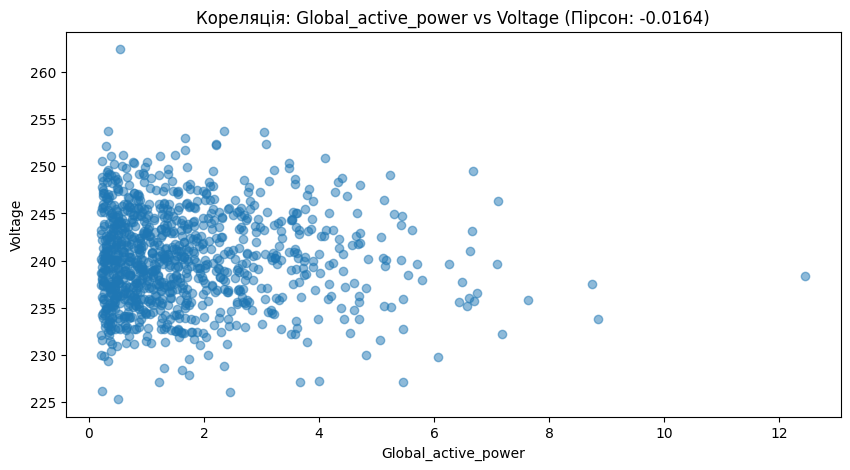

In [25]:
# Коефіцієнт Пірсона та Спірмена
print("="*60)
print("КОЕФІЦІЄНТИ КОРЕЛЯЦІЇ ПІРСОНА ТА СПІРМЕНА")
print("="*60)

# Вибір двох атрибутів
attr1 = 'Global_active_power'
attr2 = 'Voltage'

pearson_corr = df_power_clean[attr1].corr(df_power_clean[attr2], method='pearson')
spearman_corr = df_power_clean[attr1].corr(df_power_clean[attr2], method='spearman')

print(f"Кореляція між '{attr1}' та '{attr2}':")
print(f"   Коефіцієнт Пірсона: {pearson_corr:.4f}")
print(f"   Коефіцієнт Спірмена: {spearman_corr:.4f}")

# Візуалізація
plt.figure(figsize=(10, 5))
plt.scatter(df_power_clean[attr1][:1000], df_power_clean[attr2][:1000], alpha=0.5)
plt.xlabel(attr1)
plt.ylabel(attr2)
plt.title(f'Кореляція: {attr1} vs {attr2} (Пірсон: {pearson_corr:.4f})')
plt.show()

In [26]:
print("="*60)
print("ONE-HOT ENCODING")
print("="*60)

# Створення категоріального атрибута (наприклад, період дня)
def get_time_period(hour):
    if hour < 6:
        return 'Night'
    elif hour < 12:
        return 'Morning'
    elif hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

# Додаємо категоріальний атрибут
df_power_clean['Hour'] = df_power_clean.index % 24
df_power_clean['Time_Period'] = df_power_clean['Hour'].apply(get_time_period)

# One-Hot Encoding
one_hot_encoded = pd.get_dummies(df_power_clean['Time_Period'], prefix='Period')

# Об'єднання з оригінальним DataFrame
df_encoded = pd.concat([df_power_clean, one_hot_encoded], axis=1)

print("One-Hot Encoding для атрибута 'Time_Period':")
print(one_hot_encoded.head())
print(f"\nСтовпці після One-Hot Encoding: {list(one_hot_encoded.columns)}")

ONE-HOT ENCODING
One-Hot Encoding для атрибута 'Time_Period':
   Period_Afternoon  Period_Evening  Period_Morning  Period_Night
0             False           False           False          True
1             False           False           False          True
2             False           False           False          True
3             False           False           False          True
4             False           False           False          True

Стовпці після One-Hot Encoding: ['Period_Afternoon', 'Period_Evening', 'Period_Morning', 'Period_Night']
